# 🧪 Experimental Design: Feature-Based vs Cost-Based Neural TSP

This project investigates two neural approaches to solving the Travelling Salesman Problem (TSP), alongside classical baselines. The goal is to understand how representation choice affects performance, generalisation, and robustness under structural constraints.

We focus on a structured geography inspired by London, incorporating realistic spatial constraints (river crossings, bridge bottlenecks, congestion effects) during graph generation. However, the learning model itself only receives the **cost matrix**, ensuring a fair and principled TSP formulation.

---

# 🌍 Graph Generation (London-Inspired, Cost-Based)

We generate synthetic graphs that mimic structural characteristics of a real city:

* Nodes are placed in a 2D spatial region.
* A river divides the map.
* Only a limited number of bridges allow crossing.
* Congestion zones increase travel cost locally.
* Optional asymmetry can simulate directional travel effects.

From this structured geography, we compute a **cost matrix**:

$C \in \mathbb{R}^{n \times n}$

where (C_{ij}) represents the travel cost between node (i) and node (j).

Importantly:

* The RL model does **not** receive node coordinates, river side labels, or congestion indicators.
* It receives only the cost matrix (C).
* This ensures the problem is treated as a pure TSP.

This design maintains realism while preserving methodological fairness.


# 🏗 Two Neural Models

We train and compare two structurally identical attention-based reinforcement learning models that differ only in their **input representation**.

---

## 🔹 Model A — Feature-Based Representation

**Input per node:**

* Normalised spatial coordinates (x, y)
* River side indicator
* Congestion indicator

The model must learn:

* Geometric relationships
* Bridge constraints
* Congestion effects
* Implicit pairwise distances

The cost matrix is only used for computing the reward.

This setup reflects a **structured routing problem**, where the model learns from domain-specific features.

---

## 🔹 Model B — Pure Cost-Based Representation

**Input per node:**

* The row of the cost matrix:
  [
  C_i = [C_{i1}, C_{i2}, ..., C_{in}]
  ]

The model directly observes pairwise travel costs.

No coordinates, no metadata, no semantic features.

This formulation treats the problem as a **pure combinatorial TSP**, ensuring a fair comparison with classical solvers.

---

# ⚖️ Why Compare These Two?

The key research question is:

> Does learning from structured domain features outperform learning directly from pairwise costs?

The feature-based model may exploit geographic structure.
The cost-based model is more abstract and representation-aligned.

This comparison isolates the effect of representation.

---

# 🧮 Classical Baselines

To contextualise neural performance, we evaluate against:

* **Nearest Neighbour (NN)** — greedy constructive heuristic
* **2-opt** — local search refinement
* **OR-Tools** — near-optimal reference (small (n) only)

All methods operate on the same cost matrices.

---

# 📈 Generalisation to Unseen Graph Sizes

Both neural models are trained on graphs with a fixed number of nodes (e.g., (n = 50)).

We then evaluate on:

* Larger graphs (e.g., (n = 70, 100))
* Unseen configurations

This tests:

* Scalability
* Structural generalisation
* Sensitivity to problem size

Because the architecture is attention-based and permutation-invariant, it can, in principle, generalise to larger graphs.

---

# 🌐 Sparse Graph Evaluation

In addition to fully connected graphs, we test performance on **sparse TSP instances**.

Sparsity is introduced by:

* Randomly selecting a subset of edges
* Setting their cost to infinity (or a very large value)
* Ensuring connectivity is preserved
* Limiting the number of blocked edges per node

This creates an incomplete graph where certain transitions are forbidden.

This tests:

* Robustness to structural constraints
* Ability to reason under limited connectivity
* Adaptability beyond dense metric TSP

Classical solvers and neural models must both respect blocked edges.

---

# 🎯 Evaluation Criteria

For each configuration we report:

* Mean tour cost
* Runtime
* Gap to 2-opt
* Gap to OR-Tools (when feasible)

We evaluate over multiple random graph instances to ensure statistical reliability.

---

# 🧠 Broader Motivation

This study explores a fundamental question in neural combinatorial optimisation:

> Is it better to learn from raw structural features, or directly from the optimisation objective representation?

By comparing these two approaches under dense and sparse settings, and across increasing problem sizes, we gain insight into the role of representation in neural TSP solvers.




In [1]:
import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install torch torchvision torchaudio
!{sys.executable} -m pip install ortools
!{sys.executable} -m pip install matplotlib

In [2]:
import torch
import numpy as np
import time
import pandas as pd

import config

from data.london_generator import generate_london_graph
from solvers.nearest_neighbor import solve_nn
from solvers.two_opt import solve_two_opt
from solvers.ortools_solver import solve_with_ortools

from models.attention_model import AttentionTSP
from evaluation.metrics import count_river_crossings

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

features_model = AttentionTSP(
    embed_dim=config.EMBED_DIM,
    n_heads=config.N_HEADS,
    n_layers=config.N_LAYERS
).to(device)

features_model.load_state_dict(torch.load("model_final.pt", map_location=device))
features_model.eval()

print(" Features Model loaded successfully.")

 Features Model loaded successfully.


In [4]:
def greedy_decode(model, node_features, C):

    node_features = torch.tensor(node_features, dtype=torch.float32).unsqueeze(0).to(device)
    C = torch.tensor(C, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        encoded = model(node_features)

        n = node_features.shape[1]
        visited = torch.zeros(1, n, dtype=torch.bool).to(device)
        current = torch.zeros(1, dtype=torch.long).to(device)

        tour = [0]
        total_cost = 0
        visited[0, 0] = True

        for _ in range(n - 1):
            probs = model.decoder(encoded, current, visited)
            next_node = torch.argmax(probs, dim=-1)

            total_cost += C[0, current.item(), next_node.item()].item()

            visited[0, next_node] = True
            current = next_node
            tour.append(next_node.item())

        total_cost += C[0, current.item(), 0].item()
        tour.append(0)

    return tour, total_cost

In [5]:
import torch.nn as nn
class CostTSPModel(nn.Module):
    def __init__(self, n_nodes, embed_dim=128, n_heads=4, n_layers=2):
        super().__init__()

        self.input_proj = nn.Linear(n_nodes, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.value_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, C):
        # Normalize per graph
        C_norm = C / (C.max(dim=-1, keepdim=True)[0] + 1e-8)
        x = self.input_proj(C_norm)
        encoded = self.encoder(x)
        return encoded

    def decode(self, encoded, current, visited):
        query = encoded[torch.arange(encoded.size(0)), current]
        scores = torch.matmul(query.unsqueeze(1), encoded.transpose(1,2)).squeeze(1)
        scores = scores.masked_fill(visited, -1e9)
        return torch.softmax(scores, dim=-1)

    def value(self, encoded):
        graph_embed = encoded.mean(dim=1)
        return self.value_head(graph_embed).squeeze(-1)

In [6]:
def cost_model_greedy_decode(model, C):

    model.eval()

    with torch.no_grad():

        C = torch.as_tensor(C, dtype=torch.float32, device=device).unsqueeze(0)
        encoded = model(C)

        n = C.size(1)
        visited = torch.zeros(1, n, dtype=torch.bool, device=device)
        current = torch.zeros(1, dtype=torch.long, device=device)

        visited[0, 0] = True  # mark start visited

        tour = [0]
        total_cost = 0

        for _ in range(n - 1):

            probs = model.decode(encoded, current, visited)
            nxt = torch.argmax(probs, dim=-1)

            total_cost += C[0, current.item(), nxt.item()].item()

            visited[0, nxt] = True
            current = nxt
            tour.append(nxt.item())

        #  CLOSE THE TOUR
        total_cost += C[0, current.item(), 0].item()
        tour.append(0)

    return tour, total_cost

In [7]:
cost_model = CostTSPModel(50).to(device)

cost_model.load_state_dict(torch.load("cost_model_final.pt", map_location=device))
cost_model.eval()

print(" Cost Model loaded successfully.")

 Cost Model loaded successfully.


In [8]:
def time_solver(func, *args):
    start = time.perf_counter()
    result = func(*args)
    end = time.perf_counter()
    return result, end - start

In [9]:
def evaluate_instance(n_nodes=50, n_bridges=4):
    nodes, bridges, C = generate_london_graph(
        n_nodes=n_nodes,
        n_bridges=n_bridges,
        congestion_strength=config.CONGESTION_STRENGTH,
        bridge_penalty=config.BRIDGE_PENALTY,
        asymmetry_strength=config.ASYMMETRY_STRENGTH
    )

    results = []

    # NN
    (nn_tour, nn_cost), nn_time = time_solver(solve_nn, C)
    nn_cross = count_river_crossings(nn_tour, nodes)

    results.append(["NN", nn_cost, nn_cross, nn_time])

    # 2-opt
    (opt_tour, opt_cost), opt_time = time_solver(solve_two_opt, nn_tour, C)
    opt_cross = count_river_crossings(opt_tour, nodes)

    results.append(["2-opt", opt_cost, opt_cross, opt_time])

    # Attention
    (att_tour, att_cost), att_time = time_solver(greedy_decode, features_model, nodes, C)
    att_cross = count_river_crossings(att_tour, nodes)

    results.append(["features-Attention-RL", att_cost, att_cross, att_time])


    # OR-Tools (small n only)
    if n_nodes <= 220:
        (ort_tour, ort_cost), ort_time = time_solver(solve_with_ortools, C)
        ort_cross = count_river_crossings(ort_tour, nodes)
        results.append(["OR-Tools", ort_cost, ort_cross, ort_time])

    df = pd.DataFrame(results, columns=["Method", "Cost", "River Crossings", "Runtime (s)"])

    return df

In [10]:
import numpy as np
import random

def sparsify_cost_matrix(
    C,
    n_blocks=5,
    max_blocks_per_node=5,
    min_remaining_degree=5,
    inf_value=1e9,
):
    """
    Symmetrically blocks edges while trying to preserve TSP feasibility:
    - preserves connectivity via a protected spanning tree
    - enforces per-node block cap
    - enforces min remaining degree (default 2)
    NOTE: degree>=2 + connectivity does NOT strictly guarantee a Hamiltonian cycle,
    but it avoids common invalid cases.
    """
    C = C.copy()
    n = C.shape[0]

    # Build set of valid undirected edges (ignore diagonal / already-infinite)
    valid_edges = []
    for i in range(n):
        for j in range(i + 1, n):
            if np.isfinite(C[i, j]) and C[i, j] < inf_value:
                valid_edges.append((i, j))

    # Initial degree counts
    degree = np.zeros(n, dtype=int)
    for i, j in valid_edges:
        degree[i] += 1
        degree[j] += 1

    # Basic sanity: if any node starts with degree < min_remaining_degree, impossible target
    if np.any(degree < min_remaining_degree):
        raise ValueError("Input graph already has nodes with degree < min_remaining_degree.")

    # ---- Step 1: Build a protected spanning tree over existing edges ----
    # (Greedy randomized tree)
    adj = {i: [] for i in range(n)}
    for i, j in valid_edges:
        adj[i].append(j)
        

    nodes = list(range(n))
    random.shuffle(nodes)

    spanning_edges = set()
    visited = {nodes[0]}

    # Randomized BFS/Prim-like growth
    frontier = set(visited)
    while len(visited) < n:
        possible = []
        for u in frontier:
            for v in adj[u]:
                if v not in visited:
                    possible.append((min(u, v), max(u, v)))
        if not possible:
            raise ValueError("Graph appears disconnected before sparsification.")
        e = random.choice(possible)
        spanning_edges.add(e)
        visited.add(e[1] if e[0] in frontier else e[0])  # not perfect but okay
        frontier = visited.copy()

    # Track blocks per node
    block_count = np.zeros(n, dtype=int)

    # Candidate edges = valid edges not in spanning tree
    candidates = [e for e in valid_edges if e not in spanning_edges]
    random.shuffle(candidates)

    blocks_applied = 0

    for i, j in candidates:
        if blocks_applied >= n_blocks:
            break

        # per-node block cap
        if block_count[i] >= max_blocks_per_node or block_count[j] >= max_blocks_per_node:
            continue

        # degree safety (do not let either endpoint drop below min degree)
        if degree[i] - 1 < min_remaining_degree:
            continue
        if degree[j] - 1 < min_remaining_degree:
            continue

        # block edge
        C[i, j] = inf_value
        C[j, i] = inf_value

        degree[i] -= 1
        degree[j] -= 1
        block_count[i] += 1
        block_count[j] += 1
        blocks_applied += 1
    print(list(C))
    return C

In [11]:
def evaluate_multiple(n_nodes=50, n_bridges=4, n_instances=20, sparse_matrix=0):

    records = []

    for instance in range(n_instances):

        
        nodes, bridges, C = generate_london_graph(
            n_nodes=n_nodes,
            n_bridges=n_bridges,
            congestion_strength=config.CONGESTION_STRENGTH,
            bridge_penalty=config.BRIDGE_PENALTY,
            asymmetry_strength=config.ASYMMETRY_STRENGTH
        )
        
        if sparse_matrix:
            C = sparsify_cost_matrix(C)

        # ---------------- NN ----------------
        (nn_tour, nn_cost), nn_time = time_solver(solve_nn, C)
        nn_cross = count_river_crossings(nn_tour, nodes)
        #print(f"NN_tour: {nn_tour}")
        records.append(["NN", nn_cost, nn_cross, nn_time])

        # ---------------- 2-opt ----------------
        (opt_tour, opt_cost), opt_time = time_solver(solve_two_opt, nn_tour, C)
        opt_cross = count_river_crossings(opt_tour, nodes)
        #print(f"opt_tour: {opt_tour}")
        records.append(["2-opt", opt_cost, opt_cross, opt_time])

        # ---------------- Attention ----------------
        (att_tour, att_cost), att_time = time_solver(
            greedy_decode, features_model, nodes, C
        )
        att_cross = count_river_crossings(att_tour, nodes)
        #print(f"att_feauture_tour: {att_tour}")
        records.append(["Features_Attention-RL", att_cost, att_cross, att_time])

        (att_tour, att_cost), att_time = time_solver(cost_model_greedy_decode, cost_model, C)
        att_cross = count_river_crossings(att_tour, nodes)
        #print(f"cost_tour: {att_tour}")
        records.append(["Cost-Attention-RL", att_cost, att_cross, att_time])

        # ---------------- OR-Tools ----------------
        if n_nodes <= 50:  # keep small for fairness
            (ort_tour, ort_cost), ort_time = time_solver(
                solve_with_ortools, C
            )
            ort_cross = count_river_crossings(ort_tour, nodes)

            records.append(["OR-Tools", ort_cost, ort_cross, ort_time])

    df = pd.DataFrame(
        records,
        columns=["Method", "Cost", "River Crossings", "Runtime (s)"]
    )

    summary = df.groupby("Method").agg(
        Cost_mean=("Cost", "mean"),
        Cost_std=("Cost", "std"),
        Crossings_mean=("River Crossings", "mean"),
        Runtime_mean=("Runtime (s)", "mean"),
    ).reset_index()

    return summary

In [12]:
evaluate_multiple(n_nodes=50, n_bridges=4)

,Method,Cost_mean,Cost_std,Crossings_mean,Runtime_mean
0,2-opt,1013.975690,74.504362,2.0,0.056639
1,Cost-Attention-RL,1117.769657,91.819252,2.0,0.008044
2,Features_Attention-RL,1102.439810,61.149964,2.0,0.013209
3,NN,1100.986666,89.409587,2.1,0.000339
4,OR-Tools,903.450000,48.008196,2.0,10.002410


In [13]:
def scaling_test(node_sizes, bridge_count):

    records = []

    for n in node_sizes:

        df = evaluate_instance(n_nodes=n, n_bridges=bridge_count)

        for _, row in df.iterrows():
            records.append({
                "n": n,
                "Method": row["Method"],
                "Cost": row["Cost"],
                "Crossings": row["River Crossings"],
                "Runtime": row["Runtime (s)"]
            })

    return pd.DataFrame(records)

In [14]:
node_sizes = [10,20,40, 50,60,80, 100,120,150,200]

scaling_results = scaling_test(node_sizes, bridge_count=4)

scaling_results

,n,Method,Cost,Crossings,Runtime
0,10,NN,378.112049,2,0.000068
1,10,2-opt,353.884573,2,0.000323
2,10,features-Attention-RL,378.112056,2,0.003559
3,10,OR-Tools,348.000000,2,10.001365
4,20,NN,888.657083,2,0.000100
5,20,2-opt,745.651582,2,0.002195
6,20,features-Attention-RL,761.330538,2,0.006323
7,20,OR-Tools,640.000000,2,10.001311
8,40,NN,1028.841873,2,0.000206
9,40,2-opt,934.926392,2,0.030571


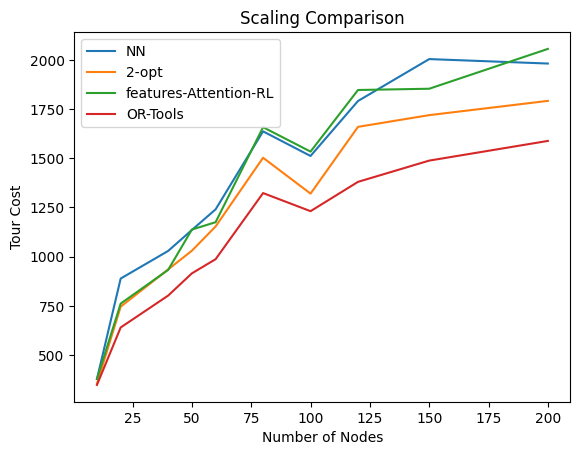

In [15]:
import matplotlib.pyplot as plt

for method in scaling_results["Method"].unique():
    subset = scaling_results[scaling_results["Method"] == method]
    plt.plot(subset["n"], subset["Cost"], label=method)

plt.xlabel("Number of Nodes")
plt.ylabel("Tour Cost")
plt.legend()
plt.title("Scaling Comparison")
plt.show()